# Figure 06X — Change-Point Exploratory Analyses (cpPlaypen)

## Background

Figure 06 characterises how participants adjust their decision bounds in response to a
mid-trial **change point (CP)** in SNR (Low→High or High→Low). In CP trials the SNR
shifts at a specific step within each trial; the pre-CP bound and post-CP bound are
estimated separately from the portions of trials before and after that step. The main
findings were:

- Participants in the **LowHigh** direction do increase their bounds post-CP (Wilcoxon p ≈ 0.02),
  and LowHigh post-CP bounds are higher than HighLow post-CP bounds (p = 0.006).
- Participants in the **HighLow** direction show no significant bound change post-CP (p ≈ 0.54).
- The RR-gradient vs. bound-change scatter (Figure 06, Row 2) shows modest Spearman correlations.

Overall the effects are variable across participants and weak. This notebook explores two
additional analyses that may reveal more robust structure:

1. **Bound change vs. CP timing** — the step at which the CP occurs varies across subjects.
   Subjects whose CP occurs earlier in the trial have more steps remaining at the new SNR,
   giving more opportunity to benefit from (and therefore to learn) the optimal post-CP bound.
   If adaptation is occurring, earlier CP steps should predict larger bound changes.

2. **Combined gradient + CP timing** — the RR gradient (benefit of adjusting the bound toward
   optimal) and the CP step are in principle independent predictors of bound adjustment. We
   examine whether they each contribute unique variance and whether their effects interact.

## Data

Same pre-computed files as Figure 06:
- `boundSummaries_wCP.mat` — per-subject pre-/post-CP bounds and stable-SNR bounds.
- `RRMats.mat` — reward-rate matrices for computing per-subject gradients.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import scipy.io
import scipy.stats
import matplotlib.pyplot as plt

from pigeon.pathDefaults import BOUND_SUMMARIES_FILE, RR_MATS_FILE

# Bound grid used by getPigeon_RRMatrix for CP (MATLAB: 0.01:0.05:0.8)
BOUNDS = np.arange(0.01, 0.81, 0.05)
TITLES = ['LowHigh', 'HighLow']

In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────────
mat    = scipy.io.loadmat(str(BOUND_SUMMARIES_FILE), squeeze_me=True, struct_as_record=False)
bs     = mat['boundSummaries']

lh_bounds = bs.LowHigh    # (n_subjects, 2): col 0 = pre-CP, col 1 = post-CP
hl_bounds = bs.HighLow
lo_bounds = bs.Low        # stable Low-SNR block bounds (n_subjects, 2)
hi_bounds = bs.High       # stable High-SNR block bounds
cp_lh     = bs.CPLowHigh  # per-subject CP step (within-trial step at which SNR shifts), LowHigh
cp_hl     = bs.CPHighLow  # same for HighLow

rr_mat = scipy.io.loadmat(str(RR_MATS_FILE), squeeze_me=True, struct_as_record=False)
pmats  = list(rr_mat['pmats'].flat)  # [LowHigh pmat, HighLow pmat]
                                      # each: (n_bounds × n_bounds × n_cp_steps)

# Use the CP step arrays from the mat file when available (saved by Make_RRMatrix.ipynb
# with cp_steps_lh / cp_steps_hl; old format used a single cp_steps field).
# These are the exact CP steps the matrix was built for, so each subject's CP step
# maps to an exact 3rd-axis index with no nearest-neighbour approximation.
if 'cp_steps_lh' in rr_mat and 'cp_steps_hl' in rr_mat:
    cp_times = [rr_mat['cp_steps_lh'], rr_mat['cp_steps_hl']]
else:
    cp_times = [np.unique(cp_lh), np.unique(cp_hl)]

# Finite-data masks (exclude subjects with missing bounds)
lh_ok = np.isfinite(lh_bounds[:, 0]) & np.isfinite(lh_bounds[:, 1])
hl_ok = np.isfinite(hl_bounds[:, 0]) & np.isfinite(hl_bounds[:, 1])

print(f'LowHigh: {lh_ok.sum()} subjects with finite bounds')
print(f'HighLow: {hl_ok.sum()} subjects with finite bounds')
print(f'CP step LowHigh: range {cp_lh.min():.0f}–{cp_lh.max():.0f}, '
      f'median {np.median(cp_lh):.1f}')
print(f'CP step HighLow: range {cp_hl.min():.0f}–{cp_hl.max():.0f}, '
      f'median {np.median(cp_hl):.1f}')
print(f'Matrix LowHigh CP steps ({len(cp_times[0])}): {cp_times[0][0]}–{cp_times[0][-1]}')
print(f'Matrix HighLow CP steps ({len(cp_times[1])}): {cp_times[1][0]}–{cp_times[1][-1]}')

---
## Section 1 — Bound change vs. CP timing

**Rationale**: In CP trials the SNR shifts at a specific within-trial step. The step at which
this occurs varies across subjects. Subjects whose CP step is early have more steps remaining
in the trial at the new SNR, so they accumulate more evidence under the new regime and have
more opportunity to benefit from — and therefore to learn — an adjusted post-CP bound.
Subjects whose CP step is late have few remaining steps; the benefit of adjusting the bound
is smaller, so there is less incentive to do so.

If participants are dynamically adjusting their bounds, earlier CP steps should predict
larger bound changes (in the appropriate direction for each condition).

For **LowHigh** the optimal adjustment is an *increase* in bound (moving from Low-SNR to
High-SNR optimal). For **HighLow** the optimal adjustment is a *decrease*. We plot raw
bound change (post − pre) for each direction; the sign of a "correct" adjustment therefore
differs between panels.

Statistics: Spearman rank correlation (robust to outliers and monotone non-linear
relationships) with a least-squares regression line for visual reference.

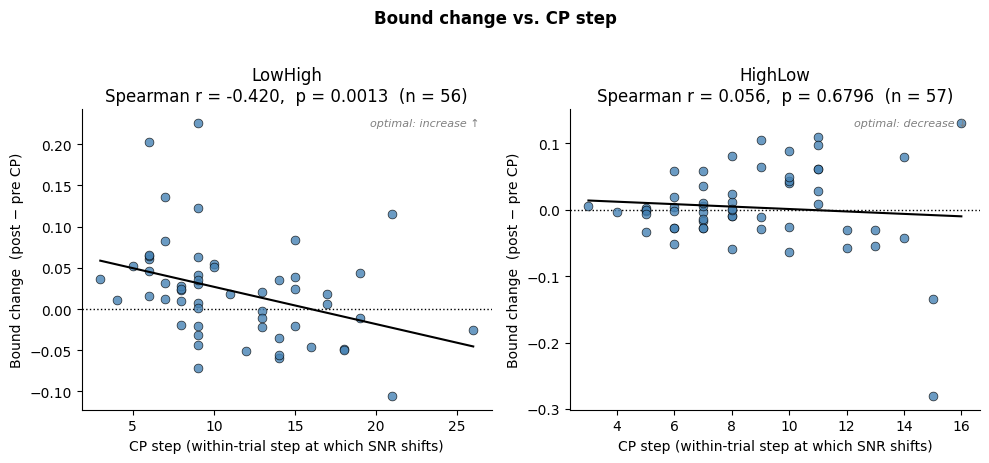

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5), sharey=False)

for tt, (ax, ok, bounds_arr, cpt, title) in enumerate(zip(
        axs,
        [lh_ok, hl_ok],
        [lh_bounds, hl_bounds],
        [cp_lh, cp_hl],
        TITLES)):

    delta = bounds_arr[ok, 1] - bounds_arr[ok, 0]  # post − pre CP bound change
    cpt_ok = cpt[ok]

    # ── Spearman correlation ───────────────────────────────────────────────────
    r, p = scipy.stats.spearmanr(cpt_ok, delta)

    # ── OLS regression line (for visual reference only; stats from Spearman) ──
    slope, intercept = np.polyfit(cpt_ok, delta, 1)
    x_line = np.linspace(cpt_ok.min(), cpt_ok.max(), 100)

    # ── Plot ──────────────────────────────────────────────────────────────────
    ax.axhline(0, color='k', linestyle=':', linewidth=1, zorder=0)  # no-change reference
    ax.scatter(cpt_ok, delta, color='steelblue', edgecolors='k',
               linewidths=0.5, s=40, zorder=2, alpha=0.8)
    ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=1.5, zorder=3)

    # ── Labels and stats ──────────────────────────────────────────────────────
    ax.set_xlabel('CP step (within-trial step at which SNR shifts)')
    ax.set_ylabel('Bound change  (post − pre CP)')
    p_str = f'{p:.4f}' if p >= 0.0001 else f'{p:.2e}'
    ax.set_title(f'{title}\nSpearman r = {r:.3f},  p = {p_str}  (n = {ok.sum()})')

    # Annotate direction of optimal adjustment so readers can interpret sign of y-axis
    opt_dir = 'optimal: increase ↑' if tt == 0 else 'optimal: decrease ↓'
    ax.text(0.97, 0.97, opt_dir, transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray', style='italic')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bound change vs. CP step', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Section 1 interpretation

A negative Spearman r means that subjects with earlier CPs (smaller step number, more
remaining steps at the new SNR) show larger bound changes in the positive direction.
For LowHigh this is the correct direction (bound should increase), so a negative r is
consistent with time-dependent adaptation.

For HighLow, where the bound should *decrease*, the logic is the same but the sign of
the correlation differs: earlier CP → more negative Δbound → as x increases y increases
(becomes less negative) → a *positive* r would indicate that earlier CPs go with larger
decreases, consistent with time-dependent adaptation.

---
## Section 2 — Combined gradient + CP timing

**Rationale**: The Figure 06 Row-2 analysis regresses bound change on the *RR gradient* —
the slope of the reward-rate surface from the subject's pre-CP bound toward the optimal
post-CP bound. A steeper gradient means more to gain from adjusting. The CP step is a
separate factor: given the same incentive, subjects with more steps remaining at the new
SNR (earlier CP step) should have more opportunity to benefit from adjusting their bound.

Here we ask:
1. How correlated are the gradient and the CP step with each other? (Are they confounded?
   Note that the gradient is computed from the RR matrix, which takes the CP step as an
   input, so some correlation is expected.)
2. Do they each carry *unique* variance in predicting bound change? (Partial correlations.)
3. Do gradient and CP step interact in predicting bound change? Rather than a median split
   (which discards information and is sensitive to the split point), this is tested formally
   below with an interaction term in a multiple regression.

**Gradient computation** (matches Figure 06): for each subject, find the optimal post-CP
bound in the RR matrix at the subject's pre-CP bound and CP step, then compute the slope
of the RR surface from the pre-CP bound to that optimum. A positive gradient means the
optimal post-CP bound is *above* the current bound (adjust upward); negative means *below*.

**Partial Spearman correlation** is computed by rank-transforming all three variables and
then taking the Pearson partial correlation on the ranks, following Conover (1999).

In [4]:
def partial_spearman(x, y, z):
    """
    Partial Spearman rank correlation of x and y, controlling for z.

    Rank-transforms all three series, then computes the Pearson partial correlation
    of the residuals after regressing out z from both x and y.

    Returns (r_partial, p_value).
    """
    rx = scipy.stats.rankdata(x)
    ry = scipy.stats.rankdata(y)
    rz = scipy.stats.rankdata(z)

    # Residualise x and y on z (linear regression on ranks)
    slope_x, int_x = np.polyfit(rz, rx, 1)
    slope_y, int_y = np.polyfit(rz, ry, 1)
    res_x = rx - (slope_x * rz + int_x)
    res_y = ry - (slope_y * rz + int_y)

    r, p = scipy.stats.pearsonr(res_x, res_y)
    return r, p


# ── Compute per-subject RR gradients ──────────────────────────────────────────
# Mirrors the Figure 06 gradient computation; stored for both CP directions.
all_grads  = [None, None]
all_deltas = [None, None]
all_cpts   = [None, None]

for tt, (bounds_arr, cpt, ok, pmat) in enumerate(zip(
        [lh_bounds, hl_bounds],
        [cp_lh, cp_hl],
        [lh_ok, hl_ok],
        pmats)):

    pre  = bounds_arr[ok, 0]   # pre-CP bound
    post = bounds_arr[ok, 1]   # post-CP bound
    cpt_ok = cpt[ok]

    grads = np.full(len(pre), np.nan)

    for pp in range(len(pre)):
        # Find which 3rd-axis slice corresponds to this subject's CP time
        cp_idx_arr = np.where(cp_times[tt] == cpt_ok[pp])[0]
        if not len(cp_idx_arr):
            continue
        cp_idx = int(cp_idx_arr[0])

        # Bin the pre-CP bound into the BOUNDS grid
        prei = int(np.clip(np.searchsorted(BOUNDS, pre[pp], 'right') - 1, 0, len(BOUNDS) - 1))

        # RR across all post-CP bounds at this pre-CP bound and CP time
        rrs  = pmat[prei, :, cp_idx]
        maxi = int(np.nanargmax(rrs))  # index of optimal post-CP bound

        if maxi == prei:
            grads[pp] = 0.0
        else:
            # Slope from current bound toward optimal (coins / trial / bound unit)
            grads[pp] = (rrs[maxi] - rrs[prei]) / (BOUNDS[maxi] - BOUNDS[prei])

    all_grads[tt]  = grads
    all_deltas[tt] = post - pre
    all_cpts[tt]   = cpt_ok

    print(f'{TITLES[tt]}: gradients computed for {np.isfinite(grads).sum()} / {len(grads)} subjects')

IndexError: index 9 is out of bounds for axis 2 with size 3

In [ ]:
# ── Pairwise and partial correlations ─────────────────────────────────────────
print('Correlations with bound change (Spearman r, p)')
print('=' * 62)

for tt in range(2):
    g = all_grads[tt]
    d = all_deltas[tt]
    c = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)  # drop any NaN subjects
    g, d, c = g[fin], d[fin], c[fin]

    r_gd,  p_gd  = scipy.stats.spearmanr(g, d)      # gradient  ↔ bound change
    r_cd,  p_cd  = scipy.stats.spearmanr(c, d)      # CP time   ↔ bound change
    r_gc,  p_gc  = scipy.stats.spearmanr(g, c)      # gradient  ↔ CP time (potential confound)
    r_gd_c, p_gd_c = partial_spearman(g, d, c)      # gradient  ↔ bound change | CP time
    r_cd_g, p_cd_g = partial_spearman(c, d, g)      # CP time   ↔ bound change | gradient

    print(f'\n{TITLES[tt]}  (n = {fin.sum()})')
    print(f'  gradient   ↔ Δbound:         r = {r_gd:.3f},  p = {p_gd:.4f}')
    print(f'  CP time    ↔ Δbound:         r = {r_cd:.3f},  p = {p_cd:.4f}')
    print(f'  gradient   ↔ CP time:        r = {r_gc:.3f},  p = {p_gc:.4f}  (confound check)')
    print(f'  gradient   ↔ Δbound | CP t:  r = {r_gd_c:.3f},  p = {p_gd_c:.4f}  (partial)')
    print(f'  CP time    ↔ Δbound | grad:  r = {r_cd_g:.3f},  p = {p_cd_g:.4f}  (partial)')

Correlations with bound change (Spearman r, p)

LowHigh  (n = 56)
  gradient   ↔ Δbound:         r = 0.339,  p = 0.0105
  CP time    ↔ Δbound:         r = -0.420,  p = 0.0013
  gradient   ↔ CP time:        r = -0.828,  p = 0.0000  (confound check)
  gradient   ↔ Δbound | CP t:  r = -0.018,  p = 0.8976  (partial)
  CP time    ↔ Δbound | grad:  r = -0.264,  p = 0.0489  (partial)

HighLow  (n = 57)
  gradient   ↔ Δbound:         r = 0.264,  p = 0.0475
  CP time    ↔ Δbound:         r = 0.056,  p = 0.6796
  gradient   ↔ CP time:        r = -0.768,  p = 0.0000  (confound check)
  gradient   ↔ Δbound | CP t:  r = 0.479,  p = 0.0002  (partial)
  CP time    ↔ Δbound | grad:  r = 0.418,  p = 0.0012  (partial)


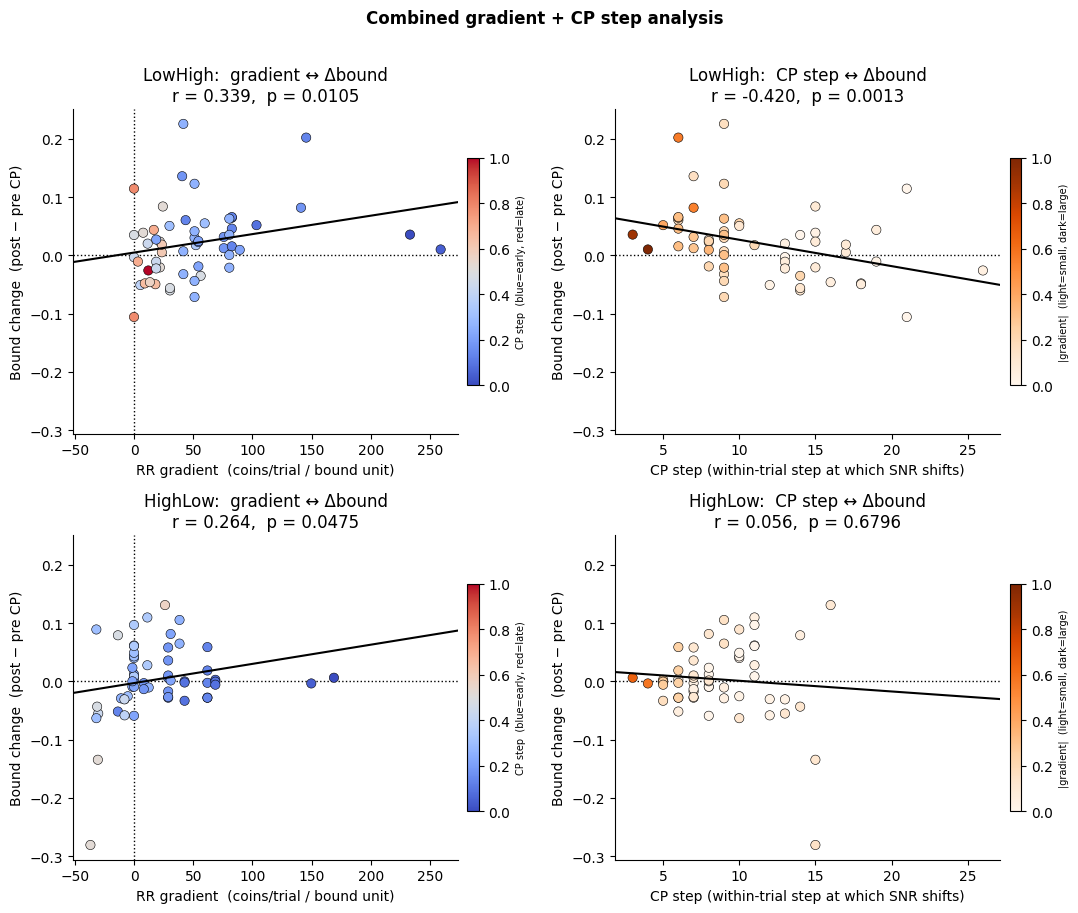

In [ ]:
# ── Combined scatter plots ─────────────────────────────────────────────────────
# Two columns per CP direction:
#   Left:  bound change vs gradient, points coloured by CP step (early=blue, late=red)
#   Right: bound change vs CP step,  points coloured by gradient magnitude (small=light, large=dark)
#
# coolwarm maps low c_norm (early CP step) to blue, high c_norm (late CP step) to red.
#
# LowHigh and HighLow rows share x/y axis limits and colour scales (computed across
# both conditions) so the two rows are directly comparable.

cond_data = []
for tt in range(2):
    g = all_grads[tt].copy()
    d = all_deltas[tt].copy()
    c = all_cpts[tt].copy()
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    cond_data.append({'g': g[fin], 'd': d[fin], 'c': c[fin]})

def _padded_lim(x, frac=0.05):
    pad = frac * (x.max() - x.min())
    return x.min() - pad, x.max() + pad

g_all = np.concatenate([cd['g'] for cd in cond_data])
d_all = np.concatenate([cd['d'] for cd in cond_data])
c_all = np.concatenate([cd['c'] for cd in cond_data])

GRAD_LIM  = _padded_lim(g_all)
DELTA_LIM = _padded_lim(d_all)
CP_LIM    = _padded_lim(c_all)

# Shared colour-scale ranges so colour means the same thing in both rows
CP_CMIN, CP_CMAX     = c_all.min(), c_all.max()
GABS_CMIN, GABS_CMAX = np.abs(g_all).min(), np.abs(g_all).max()

fig, axs = plt.subplots(2, 2, figsize=(11, 9))
cmap_time = plt.cm.coolwarm    # blue = early CP step, red = late CP step
cmap_grad = plt.cm.Oranges     # light = small |gradient|, dark = large |gradient|

for tt in range(2):
    g, d, c = cond_data[tt]['g'], cond_data[tt]['d'], cond_data[tt]['c']

    r_gd, p_gd = scipy.stats.spearmanr(g, d)
    r_cd, p_cd = scipy.stats.spearmanr(c, d)

    # Normalise using the SHARED scale (not per-condition) so colour is comparable
    c_norm = (c - CP_CMIN) / (CP_CMAX - CP_CMIN + 1e-12)
    g_norm = (np.abs(g) - GABS_CMIN) / (GABS_CMAX - GABS_CMIN + 1e-12)

    # ── Left panel: bound change vs gradient, coloured by CP step ────────────
    ax_l = axs[tt, 0]
    ax_l.axhline(0, color='k', linestyle=':', linewidth=1, zorder=0)
    ax_l.axvline(0, color='k', linestyle=':', linewidth=1, zorder=0)

    sc = ax_l.scatter(g, d, c=c_norm, cmap=cmap_time, vmin=0, vmax=1,
                      edgecolors='k', linewidths=0.4, s=45, zorder=2)

    # Regression line
    slope, intercept = np.polyfit(g, d, 1)
    x_line = np.linspace(*GRAD_LIM, 100)
    ax_l.plot(x_line, slope * x_line + intercept, 'k-', linewidth=1.5, zorder=3)

    p_str = f'{p_gd:.4f}' if p_gd >= 0.0001 else f'{p_gd:.2e}'
    ax_l.set_title(f'{TITLES[tt]}:  gradient ↔ Δbound\nr = {r_gd:.3f},  p = {p_str}')
    ax_l.set_xlabel('RR gradient  (coins/trial / bound unit)')
    ax_l.set_ylabel('Bound change  (post − pre CP)')
    ax_l.set_xlim(GRAD_LIM)
    ax_l.set_ylim(DELTA_LIM)

    cbar_l = fig.colorbar(sc, ax=ax_l, shrink=0.7, pad=0.02)
    cbar_l.set_label('CP step  (blue=early, red=late)', fontsize=7)

    ax_l.spines['top'].set_visible(False)
    ax_l.spines['right'].set_visible(False)

    # ── Right panel: bound change vs CP step, coloured by |gradient| ─────────
    ax_r = axs[tt, 1]
    ax_r.axhline(0, color='k', linestyle=':', linewidth=1, zorder=0)

    sc2 = ax_r.scatter(c, d, c=g_norm, cmap=cmap_grad, vmin=0, vmax=1,
                       edgecolors='k', linewidths=0.4, s=45, zorder=2)

    slope2, intercept2 = np.polyfit(c, d, 1)
    x_line2 = np.linspace(*CP_LIM, 100)
    ax_r.plot(x_line2, slope2 * x_line2 + intercept2, 'k-', linewidth=1.5, zorder=3)

    p_str2 = f'{p_cd:.4f}' if p_cd >= 0.0001 else f'{p_cd:.2e}'
    ax_r.set_title(f'{TITLES[tt]}:  CP step ↔ Δbound\nr = {r_cd:.3f},  p = {p_str2}')
    ax_r.set_xlabel('CP step (within-trial step at which SNR shifts)')
    ax_r.set_ylabel('Bound change  (post − pre CP)')
    ax_r.set_xlim(CP_LIM)
    ax_r.set_ylim(DELTA_LIM)

    cbar_r = fig.colorbar(sc2, ax=ax_r, shrink=0.7, pad=0.02)
    cbar_r.set_label('|gradient|  (light=small, dark=large)', fontsize=7)

    ax_r.spines['top'].set_visible(False)
    ax_r.spines['right'].set_visible(False)

plt.suptitle('Combined gradient + CP step analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Reading the combined scatter plots

LowHigh and HighLow panels share x/y axis limits (and colour scales) within each column,
so the two conditions can be compared directly.

- **Left panels** (gradient ↔ Δbound, coloured by CP step): If the gradient drives adjustment
  independently of timing, the regression line should be positive (for both conditions: larger
  gradient magnitude in the direction of optimal → larger adjustment) and early-CP points (blue)
  should not cluster systematically above or below late-CP points (red) at any given gradient value.

- **Right panels** (CP step ↔ Δbound, coloured by |gradient|): If earlier CP steps drive
  larger adjustment independently of the gradient, the regression line should be **negative for
  LowHigh** (earlier step = smaller x → larger increase = larger y) and **positive for HighLow**
  (earlier step = smaller x → larger decrease = more negative y, so y increases as x increases).
  Large-gradient subjects (dark) should not cluster disproportionately among the early-CP subjects
  if gradient and timing are independent.

Partial correlations (printed above) quantify these questions directly: `gradient ↔ Δbound | CP step`
asks how much unique variance the gradient explains once the CP step is partialled out, and vice versa.
The standardized regression below formalises this further, adding an explicit interaction term.

### Standardized regression: gradient × CP step interaction

To test formally whether bound change depends on the RR gradient, the CP step, and their
interaction — without throwing away information via a median split — we fit, separately
for each condition:

```
Δbound ~ gradient + CP_step + gradient:CP_step
```

**Standardization — rank-based, not raw z-scores**: every other statistic in this notebook
(Section 1, the pairwise/partial correlations, the scatter-plot titles) uses **Spearman**
rank correlation specifically because the gradient is heavy-tailed (a near-zero denominator
in the gradient calculation can produce a few very large values, well outside the bulk of
the distribution — visible as the wide `GRAD_LIM` range in the combined scatter plots above).
If we standardize by simply z-scoring the *raw* values, those few extreme points dominate the
linear (Pearson-type) fit. To keep this regression consistent with the rest of the notebook
(and robust to those outliers), we **rank-transform** gradient, CP step, and Δbound first,
then z-score the ranks. The single-predictor version of this regression is mathematically
identical to the Spearman correlations reported above (R² of `Δbound ~ CP_step` on ranks
equals the Spearman rho² for CP step vs. Δbound).

**Why the regression's significance pattern looks "reversed" from the scatter plots**: the
scatter-plot titles show *marginal* (bivariate) correlations — gradient and CP step each
correlated with Δbound on their own, ignoring the other predictor. The regression instead
estimates each predictor's *unique* contribution after the other is held constant. Because
gradient and CP step are themselves strongly correlated (Spearman r ≈ -0.77 to -0.83 in both
conditions — the gradient is computed *from* the RR matrix using the CP step as an input),
marginal and partial/unique effects can differ substantially, even change which predictor
looks "significant." This is the standard statistical phenomenon of **suppression /
redundancy among collinear predictors**, not an error — and it is independently confirmed
below by comparing the regression's main-effect coefficients to the partial Spearman
correlations already computed earlier in this notebook (cell `d0e1f2a3`), which were derived
by a completely different method (rank-residualization, not regression).

The interaction term is the product of the two standardized rank variables. Because an
"interaction of ranks" is a less standard quantity than an interaction of raw values, its
significance is also checked below with a permutation test — a model-free method that does
not depend on OLS assumptions or on the specific choice of rank transform — to make sure it
is not an artifact of the rank transform.

In [ ]:
# ── Standardized regression per condition (rank-based, consistent with Spearman) ──
import statsmodels.formula.api as smf
import pandas as pd


def zscore(x):
    return (x - x.mean()) / x.std(ddof=1)


def rank_zscore(x):
    """Rank-transform then z-score — puts the regression on the same robust,
    monotone-only footing as the Spearman correlations used throughout this
    notebook, and avoids giving outliers in the heavy-tailed gradient undue
    leverage over the fit."""
    return zscore(scipy.stats.rankdata(x))


regression_results = {}

print('Rank-based standardized regression: '
      'rank_z(Δbound) ~ rank_z(gradient) + rank_z(CP step) + rank_z(gradient)×rank_z(CP step)')
print('=' * 96)

for tt in range(2):
    g = all_grads[tt]
    d = all_deltas[tt]
    c = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    df = pd.DataFrame({
        'delta_z':    rank_zscore(d),
        'gradient_z': rank_zscore(g),
        'cp_step_z':  rank_zscore(c),
    })
    model = smf.ols('delta_z ~ gradient_z + cp_step_z + gradient_z:cp_step_z', data=df).fit()
    regression_results[TITLES[tt]] = model

    print(f'\n{TITLES[tt]}  (n = {fin.sum()})')
    print(f'  R² = {model.rsquared:.3f}   adj-R² = {model.rsquared_adj:.3f}   '
          f'F-test p = {model.f_pvalue:.4f}')
    print(f'  {"term":<24s}{"beta":>9s}{"SE":>9s}{"t":>9s}{"p":>9s}')
    for name in ['Intercept', 'gradient_z', 'cp_step_z', 'gradient_z:cp_step_z']:
        b, se, t, p = model.params[name], model.bse[name], model.tvalues[name], model.pvalues[name]
        print(f'  {name:<24s}{b:>+9.3f}{se:>9.3f}{t:>+9.3f}{p:>9.4f}')

Rank-based standardized regression: rank_z(Δbound) ~ rank_z(gradient) + rank_z(CP step) + rank_z(gradient)×rank_z(CP step)

LowHigh  (n = 56)
  R² = 0.183   adj-R² = 0.136   F-test p = 0.0141
  term                         beta       SE        t        p
  Intercept                  -0.071    0.171   -0.416   0.6790
  gradient_z                 -0.038    0.224   -0.169   0.8661
  cp_step_z                  -0.451    0.224   -2.014   0.0492
  gradient_z:cp_step_z       -0.087    0.144   -0.607   0.5467

HighLow  (n = 57)
  R² = 0.369   adj-R² = 0.333   F-test p = 0.0000
  term                         beta       SE        t        p
  Intercept                  +0.300    0.140   +2.145   0.0366
  gradient_z                 +0.802    0.171   +4.688   0.0000
  cp_step_z                  +0.632    0.170   +3.711   0.0005
  gradient_z:cp_step_z       +0.398    0.117   +3.385   0.0013


In [ ]:
# ── Validation 1: do the main effects match the already-computed partial correlations? ──
# partial_spearman (defined above) and this regression's main-effect coefficients are
# computed by two unrelated methods (rank-residualization vs. multiple OLS on ranks).
# If they agree, the "reversal" relative to the marginal scatter-plot correlations is a
# real suppression/collinearity effect, not a quirk of the regression.

print('Regression main effects (no interaction) vs. partial Spearman correlations')
print('=' * 88)

for tt in range(2):
    g = all_grads[tt]
    d = all_deltas[tt]
    c = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    r_gd_c, p_gd_c = partial_spearman(g, d, c)   # gradient ↔ Δbound | CP step
    r_cd_g, p_cd_g = partial_spearman(c, d, g)   # CP step  ↔ Δbound | gradient

    df = pd.DataFrame({
        'delta_z':    rank_zscore(d),
        'gradient_z': rank_zscore(g),
        'cp_step_z':  rank_zscore(c),
    })
    m_noint = smf.ols('delta_z ~ gradient_z + cp_step_z', data=df).fit()

    print(f'\n{TITLES[tt]}')
    print(f'  gradient | CP step:  partial r = {r_gd_c:+.3f} (p={p_gd_c:.4f})   '
          f'vs. regression β = {m_noint.params["gradient_z"]:+.3f} (p={m_noint.pvalues["gradient_z"]:.4f})')
    print(f'  CP step | gradient:  partial r = {r_cd_g:+.3f} (p={p_cd_g:.4f})   '
          f'vs. regression β = {m_noint.params["cp_step_z"]:+.3f} (p={m_noint.pvalues["cp_step_z"]:.4f})')

Regression main effects (no interaction) vs. partial Spearman correlations

LowHigh
  gradient | CP step:  partial r = -0.018 (p=0.8976)   vs. regression β = -0.029 (p=0.8985)
  CP step | gradient:  partial r = -0.264 (p=0.0489)   vs. regression β = -0.444 (p=0.0510)

HighLow
  gradient | CP step:  partial r = +0.479 (p=0.0002)   vs. regression β = +0.747 (p=0.0002)
  CP step | gradient:  partial r = +0.418 (p=0.0012)   vs. regression β = +0.629 (p=0.0013)


In [ ]:
# ── Validation 2: is the gradient × CP step interaction real, or a rank-transform artifact? ──
# Permutation test: shuffle CP step across subjects (destroying any true relationship
# between CP step and Δbound, including the interaction), refit, and record the
# interaction coefficient. Repeating this many times gives a null distribution for the
# interaction coefficient under "no true effect of CP step" — a model-free check that
# does not depend on OLS assumptions or on the specific choice of rank transform.

rng = np.random.default_rng(0)
n_perm = 2000

perm_results = {}  # {title: (observed beta, permutation p)} — reused in the Section 3 summary table

print('Permutation test for the gradient × CP step interaction term')
print('=' * 88)

for tt in range(2):
    g = all_grads[tt]
    d = all_deltas[tt]
    c = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    gz, dz, cz = rank_zscore(g), rank_zscore(d), rank_zscore(c)
    df = pd.DataFrame({'delta_z': dz, 'gradient_z': gz, 'cp_step_z': cz})
    obs_model = smf.ols('delta_z ~ gradient_z + cp_step_z + gradient_z:cp_step_z', data=df).fit()
    obs_beta = obs_model.params['gradient_z:cp_step_z']

    perm_betas = np.empty(n_perm)
    for i in range(n_perm):
        c_perm = rng.permutation(cz)
        df_p = pd.DataFrame({'delta_z': dz, 'gradient_z': gz, 'cp_step_z': c_perm})
        perm_betas[i] = smf.ols('delta_z ~ gradient_z + cp_step_z + gradient_z:cp_step_z',
                                 data=df_p).fit().params['gradient_z:cp_step_z']

    p_perm = (np.abs(perm_betas) >= np.abs(obs_beta)).mean()
    perm_results[TITLES[tt]] = (obs_beta, p_perm)
    print(f'{TITLES[tt]}: observed interaction β = {obs_beta:+.3f},  '
          f'permutation p = {p_perm:.4f}  (n_perm = {n_perm})')

Permutation test for the gradient × CP step interaction term
LowHigh: observed interaction β = -0.087,  permutation p = 0.5060  (n_perm = 2000)
HighLow: observed interaction β = +0.398,  permutation p = 0.0055  (n_perm = 2000)


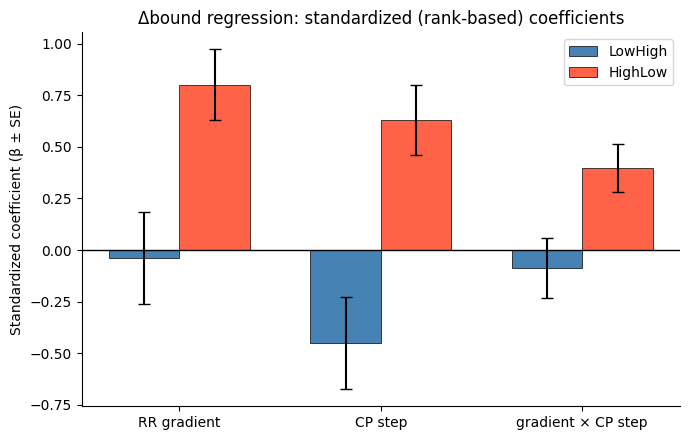

In [ ]:
# ── Visual comparison of standardized coefficients across conditions ─────────
# Because all variables were rank-transformed and z-scored, betas are directly
# comparable across terms and across LowHigh vs. HighLow. Error bars show ±1 SE.

terms       = ['gradient_z', 'cp_step_z', 'gradient_z:cp_step_z']
term_labels = ['RR gradient', 'CP step', 'gradient × CP step']

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(terms))
width = 0.35

for offset, title, color in [(-width / 2, 'LowHigh', 'steelblue'),
                              (width / 2, 'HighLow', 'tomato')]:
    model = regression_results[title]
    betas = [model.params[t] for t in terms]
    ses   = [model.bse[t] for t in terms]
    ax.bar(x + offset, betas, width, yerr=ses, capsize=4, label=title,
           color=color, edgecolor='k', linewidth=0.5)

ax.axhline(0, color='k', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(term_labels)
ax.set_ylabel('Standardized coefficient (β ± SE)')
ax.set_title('Δbound regression: standardized (rank-based) coefficients')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Reading the regression results

- **Marginal vs. unique effects**: the scatter-plot titles report *marginal* correlations
  (each predictor on its own); the regression's main-effect coefficients report each
  predictor's *unique* contribution once the other is held constant. Because gradient and
  CP step are themselves strongly correlated, these can differ a lot — sometimes a predictor
  that looks significant on its own (LowHigh's gradient) turns out to carry no unique
  information once CP step is accounted for, and sometimes a predictor that looks
  non-significant on its own (HighLow's CP step) turns out to have a strong unique effect
  once gradient is accounted for. **Validation 1** above confirms this is real and not a
  regression artifact: the main-effect coefficients match the partial Spearman correlations
  computed independently (via rank-residualization, not regression) earlier in the notebook.
- **The interaction term**: a significant **gradient_z:cp_step_z** coefficient means the
  effect of the gradient on bound change depends on how early/late the CP step was (or
  equivalently, the effect of CP step depends on the gradient) — a synergistic effect that no
  single 2D scatter plot can show, since it requires varying both predictors jointly.
  **Validation 2** above confirms this is real for HighLow (significant by permutation test,
  which makes no assumptions about the rank transform or OLS) and genuinely absent for
  LowHigh (not significant by the same test) — so the difference between conditions is a
  property of the data, not of the method.
- Because every term is standardized (rank-based), the bar chart above lets you compare
  effect sizes directly: which predictor (gradient, CP step, or their interaction) has the
  largest unique contribution, and whether that pattern is the same or different for
  LowHigh vs. HighLow.

---
## Section 3 — Compact summary for reporting

Gradient and CP step are too collinear (Spearman r ≈ -0.77 to -0.83) to report as two
independent bivariate plots without context — a reader would see two "significant"
correlations and not realize they are largely the same signal counted twice. The figure
below keeps the gradient-only scatter from Figure 06 (Row 2) for visual continuity, but
adds the **partial** correlation (gradient ↔ Δbound, controlling for CP step) directly in
the panel, so the marginal and unique effects are both visible at a glance. The table below
adds the CP step's own marginal/partial correlations and the interaction term, with the
gradient↔CP step collinearity reported alongside as an explicit caveat.

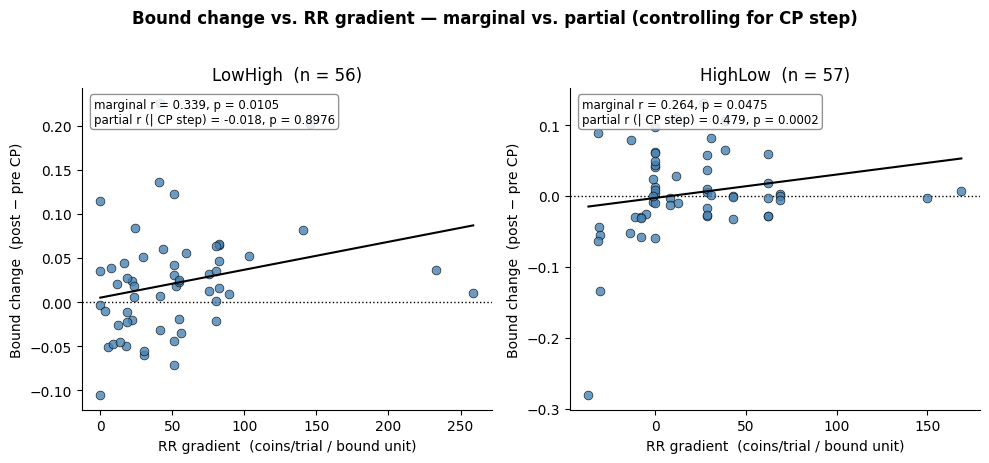

In [ ]:
# ── Compact figure: gradient-only scatter, annotated with marginal + partial r ──
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

for tt, ax in enumerate(axs):
    g = all_grads[tt]
    d = all_deltas[tt]
    c = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    r_marg, p_marg = scipy.stats.spearmanr(g, d)
    r_part, p_part = partial_spearman(g, d, c)

    ax.axhline(0, color='k', linestyle=':', linewidth=1, zorder=0)
    ax.scatter(g, d, color='steelblue', edgecolors='k', linewidths=0.5, s=40, alpha=0.8, zorder=2)

    slope, intercept = np.polyfit(g, d, 1)
    x_line = np.linspace(g.min(), g.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=1.5, zorder=3)

    p_marg_str = f'{p_marg:.4f}' if p_marg >= 0.0001 else f'{p_marg:.2e}'
    p_part_str = f'{p_part:.4f}' if p_part >= 0.0001 else f'{p_part:.2e}'
    annot = (f'marginal r = {r_marg:.3f}, p = {p_marg_str}\n'
             f'partial r (| CP step) = {r_part:.3f}, p = {p_part_str}')
    ax.text(0.03, 0.97, annot, transform=ax.transAxes, ha='left', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'))

    ax.set_title(f'{TITLES[tt]}  (n = {fin.sum()})')
    ax.set_xlabel('RR gradient  (coins/trial / bound unit)')
    ax.set_ylabel('Bound change  (post − pre CP)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Bound change vs. RR gradient — marginal vs. partial (controlling for CP step)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Compact table: marginal, partial, interaction, and the collinearity caveat ──
def fmt(r, p):
    p_str = f'{p:.4f}' if p >= 0.0001 else f'{p:.2e}'
    return f'{r:+.3f} (p={p_str})'

rows = []
for tt in range(2):
    g = all_grads[tt]
    d = all_deltas[tt]
    c = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    r_gd, p_gd     = scipy.stats.spearmanr(g, d)
    r_cd, p_cd     = scipy.stats.spearmanr(c, d)
    r_gc, p_gc     = scipy.stats.spearmanr(g, c)
    r_gd_c, p_gd_c = partial_spearman(g, d, c)
    r_cd_g, p_cd_g = partial_spearman(c, d, g)
    beta_int, p_int = perm_results[TITLES[tt]]

    rows.append({
        'Condition': TITLES[tt],
        'n': fin.sum(),
        'gradient ↔ Δbound (marginal)':            fmt(r_gd, p_gd),
        'CP step ↔ Δbound (marginal)':              fmt(r_cd, p_cd),
        'gradient ↔ Δbound | CP step (partial)':    fmt(r_gd_c, p_gd_c),
        'CP step ↔ Δbound | gradient (partial)':    fmt(r_cd_g, p_cd_g),
        'gradient × CP step interaction (perm.)':   fmt(beta_int, p_int),
        'gradient ↔ CP step (collinearity)':        f'{r_gc:+.3f}',
    })

summary_df = pd.DataFrame(rows)
summary_df

,Condition,n,gradient ↔ Δbound (marginal),CP step ↔ Δbound (marginal),gradient ↔ Δbound | CP step (partial),CP step ↔ Δbound | gradient (partial),gradient × CP step interaction (perm.),gradient ↔ CP step (collinearity)
0,LowHigh,56,+0.339 (p=0.0105),-0.420 (p=0.0013),-0.018 (p=0.8976),-0.264 (p=0.0489),-0.087 (p=0.5060),-0.828
1,HighLow,57,+0.264 (p=0.0475),+0.056 (p=0.6796),+0.479 (p=0.0002),+0.418 (p=0.0012),+0.398 (p=0.0055),-0.768


In [ ]:
# ── Why do the conditions differ? Check whether the *direction* the gradient recommends
#    (increase vs. decrease), not just its magnitude, depends on CP timing ──
# If "increase the bound" / "decrease the bound" were the qualitatively correct call
# regardless of when the CP happens, the sign of the gradient should not flip with CP
# step — only its magnitude should shrink for late CPs. If instead the qualitatively
# correct call itself depends on how much trial remains, the sign should flip from
# positive (increase) at early CP steps to negative (decrease) at late CP steps.

print('Fraction of subjects whose RR gradient recommends an INCREASE, split by CP timing')
print('=' * 88)

for tt in range(2):
    g = all_grads[tt]
    d = all_deltas[tt]
    c = all_cpts[tt]
    fin = np.isfinite(g) & np.isfinite(d) & np.isfinite(c)
    g, d, c = g[fin], d[fin], c[fin]

    med_c = np.median(c)
    early, late = c <= med_c, c > med_c

    print(f'\n{TITLES[tt]}  (median CP step = {med_c:.1f}, n = {fin.sum()})')
    print(f'  early CP (step ≤ {med_c:.0f}, n={early.sum():2d}):  '
          f'{(g[early] > 0).mean()*100:5.1f}% recommend increase,  mean gradient = {g[early].mean():+7.1f}')
    print(f'  late  CP (step >  {med_c:.0f}, n={late.sum():2d}):  '
          f'{(g[late] > 0).mean()*100:5.1f}% recommend increase,  mean gradient = {g[late].mean():+7.1f}')

Fraction of subjects whose RR gradient recommends an INCREASE, split by CP timing

LowHigh  (median CP step = 9.0, n = 56)
  early CP (step ≤ 9, n=30):  100.0% recommend increase,  mean gradient =   +80.7
  late  CP (step >  9, n=26):   84.6% recommend increase,  mean gradient =   +19.6

HighLow  (median CP step = 8.0, n = 57)
  early CP (step ≤ 8, n=32):   78.1% recommend increase,  mean gradient =   +38.3
  late  CP (step >  8, n=25):   24.0% recommend increase,  mean gradient =    -4.3


### Interpreting the table — and why LowHigh and HighLow differ

**Reading the table term by term**

- **Marginal correlations** (each predictor considered alone) suggest, at face value, that
  LowHigh is driven by *both* gradient and CP step, while HighLow is driven by gradient
  only (CP step's marginal r = 0.056, p = 0.68 — apparently nothing there).
- **Partial correlations** (each predictor's contribution once the other is held fixed)
  overturn that impression for both conditions, but in *opposite* ways:
  - **LowHigh**: gradient's partial effect collapses to ~0 (r = -0.018, down from a "real-looking"
    marginal r = 0.339), while CP step survives (partial r = -0.264). This is **redundancy**:
    gradient's marginal correlation with Δbound was almost entirely borrowed from its strong
    correlation with CP step (r = -0.828) — once CP step is in the model, gradient adds
    essentially nothing.
  - **HighLow**: both partial correlations are *larger* than their marginal counterparts
    (gradient: 0.264 → 0.479; CP step: 0.056 → 0.418). This is the textbook signature of
    **classical suppression** — gradient and CP step are negatively correlated (r = -0.768)
    but each pushes Δbound in the *same* direction, so each one's marginal correlation is
    partly cancelled by the other until you statistically remove that overlap.
  - The **interaction** is significant only for HighLow (β = +0.398, permutation p ≈ 0.005);
    for LowHigh it is small and not significant (β = -0.087, p ≈ 0.51). HighLow's regression
    also explains roughly twice the variance (R² = 0.369 vs. 0.183) — consistent with an
    interaction-dependent process being genuinely better described by this model than
    LowHigh's simpler, single-predictor process.

**Why would the two conditions differ this way? A normative account, grounded in the RR matrix**

The cell above tests this directly: does the *direction* the RR gradient recommends
(increase vs. decrease) depend on CP timing, or is it fixed by the SNR-change direction
alone?

- **LowHigh**: the gradient recommends an *increase* for essentially everyone, regardless of
  timing — 100% of early-CP subjects and 85% of late-CP subjects. Only the *magnitude* shrinks
  for late CPs (mean +80.7 early vs. +19.6 late). Going from low to high SNR, raising the
  bound is close to a free lunch: the new, more reliable evidence makes each extra step of
  accumulation cheap, so the qualitatively correct response barely depends on how much trial
  remains — only *how much* to raise it does. That is exactly the pattern a regression would
  show as one dominant, non-interacting predictor (CP step, which sets the available "budget"
  for the increase) and a redundant second one (gradient, which mostly just restates the
  timing in reward-rate units).
- **HighLow**: the recommended *direction itself* flips with timing — 78% of early-CP subjects
  get a gradient recommending an *increase* (mean +38.3), while only 24% of late-CP subjects do
  (mean gradient turns negative, -4.3). In other words, "decrease your bound" is only the
  RR-optimal response to a high→low CP when *little trial time remains*; if the CP happens
  early enough, there are still enough low-SNR steps left that accumulating more evidence
  (a higher bound) outweighs the lower per-sample reliability. Because the correct
  qualitative response is itself a joint function of SNR change *and* remaining time, no
  single predictor can capture it — hence the genuine interaction, the suppression pattern
  in the partial correlations, and the higher R².
- This also reconciles the regression results with the **group-level** finding in the notebook
  introduction: LowHigh shows a robust group-average increase (Wilcoxon p ≈ 0.02) because
  almost everyone's optimal direction agrees regardless of timing, so the average doesn't
  cancel out. HighLow shows *no* group-average change (p ≈ 0.54) not because individuals
  aren't adjusting, but because the optimal direction is split roughly with CP timing across
  subjects (mean Δbound here: +0.022 LowHigh vs. +0.004 HighLow, and only 49% of HighLow
  subjects move in the naively-"expected" decrease direction, vs. 66% of LowHigh subjects
  moving in the expected increase direction) — the individual-level adjustments partly cancel
  in the group mean, but the gradient × CP step interaction recovers the structure that the
  mean obscures.

**Caveat**: this is a model-based account — it explains what the RR matrix says is optimal
given each subject's actual pre-CP bound and CP step, using the same matrix used throughout
this notebook. It is offered as a plausible normative reason the two conditions differ, not as
direct evidence of what pigeons are actually computing.